In [9]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/sdtools"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/general_functions"))

# from plotting_functions import *
# from convergence_functions import * 
from claude_convergence_refactor import *

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
plt.style.use('default')
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# I/O

In [2]:
ds = Load.case_1D('/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2025-03_updated_glimmer/single_core_cold_start', guard_replace = False, use_squash=True).ds

- Looking for squash file
- Squash file found. squash date 04/20/2025, 19:32:36, dmp file date 04/07/2025, 17:48:56
Skipping unnormalisation


In [ ]:
# def log_formatter():
#     """
#     Creates and returns a LogFormatter for use in plotting log-scaled data.
    
#     This formatter will format the y-axis ticks to show non-scientific notation
#     when the values are powers of 10, and scientific notation for others.

#     Returns:
#     LogFormatter: The formatter for logarithmic scale.
#     """
#     return LogFormatter(base=10.0, labelOnlyBase=False)


# def replace_guards(var):
#     """
#     This in-place replaces the points in the guard cells with the points 
#     on the boundary.
#     """
#     var = var[1:-1]  # Strip the edge guard cells

#     var[0] = 0.5 * (var[0] + var[1])
#     var[-1] = 0.5 * (var[-1] + var[-2])
    
#     return var

# def find_first_below_threshold(temp_profile, y_values, threshold=5.0):
#     """
#     Finds the first location where the temperature drops below a given threshold.

#     Parameters:
#     temp_profile (np.array): The temperature profile along the spatial axis.
#     y_values (np.array): The spatial locations corresponding to the temperature values.
#     threshold (float): The temperature threshold to check against (default is 5 eV).

#     Returns:
#     float: The y-position where the temperature first drops below the threshold, or None if not found.
#     """
#     below_threshold = np.where(temp_profile < threshold)[0]
    
#     if len(below_threshold) > 0:
#         return y_values[below_threshold[0]]  # Return the first position
#     else:
#         return None  # Return None if no location is found below the threshold


# # def detachment_front_finder(ds, last_time_slice=True, use_temperature=True):
# #     """
# #     Finds the location of the detachment front. Optionally, it can be determined
# #     by the first cell where Te <= 5.

# #     Parameters:
# #     ds (xarray Dataset): The dataset for a single time slice.
# #     use_temperature (bool): If True, the front is determined by the first cell where Te <= 5.
# #                             If False, the front is determined where Nd > Ne.

# #     Returns:
# #     float: The y-coordinate of the detachment front, 
# #            or zero if the front position is undefined or non-positive.
# #     """
# #     Nd = replace_guards(np.ravel(ds['Nd']))
# #     Ne = replace_guards(np.ravel(ds['Ne']))
# #     Te = replace_guards(np.ravel(ds['Te']))  # Adding temperature field
# #     y = ds['y'][1:-1]  # Exclude guards from y coordinate

# #     if use_temperature:
# #         # Find the first index where Te <= 5
# #         detachment_indices = np.where(Te <= 5)[0]
# #     else:
# #         # Find the first index where Nd > Ne
# #         detachment_indices = np.where(Nd > Ne)[0]

# #     if len(detachment_indices) > 0:
# #         front_loc = y[detachment_indices[0]]
# #         front_position = y[-1].values - front_loc.values  # Relative to y-max
# #         return max(front_position, 0)  # Ensure non-negative output
# #     else:
# #         return 0  # Set to zero if detachment front not found or undefined

# # def plot_time_history(dataset, variables=['Te'], upstream_index=2, target_index=-2,
# #                       track_detachment_front=True, time_slices=800,
# #                       log_threshold=1e6, base_figsize=(6, 4), save=False, det_specification = 'Te'):
# #     """
# #     Plots the time history of user-specified variables at upstream and target positions
# #     on separate plots, using the last 200 time slices or the maximum available.

# #     Optionally tracks the detachment front, where Nd > Ne, and adds it as a separate subplot.

# #     Parameters:
# #     dataset (xarray Dataset): Hermes-3 dataset.
# #     variables (list): List of variables to plot (e.g., ['Te', 'Td+', 'Ne']).
# #     upstream_index (int): Index for the upstream data.
# #     target_index (int): Index for the target data.
# #     track_detachment_front (bool): If True, track the location where Nd > Ne
# #                                    and show it as a separate subplot.
# #     log_threshold (float): Threshold above which the y-axis will be plotted in log scale.
# #     base_figsize (tuple): Base figure size for a single plot (width, height).
# #     """
# #     # Determine how many time steps to plot (maximum 200 or the total available)
# #     num_time_slices = min(time_slices, dataset.sizes['t'])

# #     # Select the last `num_time_slices` time steps
# #     selected_steps = dataset.isel(t=slice(-num_time_slices, None))
# #     times = selected_steps['t'].values 
# #     t_conversion = dataset['t'].attrs.get('conversion', 1.0)
# #     # times = times * t_conversion  
# #     times = times * 1e3  # Convert to milliseconds for plotting

# #     # Find the last time step in milliseconds
# #     last_time_step = times[-1]

# #     # Adjust the number of subplots based on whether we're tracking detachment front
# #     total_vars = len(variables) + (1 if track_detachment_front else 0)

# #     # Dynamically scale figure size based on number of variables
# #     figsize = (base_figsize[0] * total_vars, base_figsize[1] * 2)

# #     # Create figure with subplots, one set for upstream and one for target, plus detachment front if enabled
# #     fig, axs = plt.subplots(2, total_vars, figsize=figsize, dpi=200)

# #     # Ensure axs is treated as a list if there's only one plot
# #     if total_vars == 1:
# #         axs = [axs[0], axs[1]]

# #     axs = np.ravel(axs)  # Flatten the axes for easy handling

# #     # Variable to store positions where Nd > Ne (detachment front)
# #     detachment_front_positions = [] if track_detachment_front else None

# #     if det_specification == 'Te':

# #     # If tracking the detachment front, calculate it for each time slice
# #         if track_detachment_front:
# #             front_positions = []
# #             for t_step in range(num_time_slices):
# #                 ds_at_t = selected_steps.isel(t=t_step)
# #                 front_loc = detachment_front_finder(ds_at_t, use_temperature=True)
# #                 front_positions.append(front_loc)
# #             detachment_front_positions = np.array(front_positions)
    
# #     elif det_specification == 'Nd':
# #         if track_detachment_front:
# #             front_positions = []
# #             for t_step in range(num_time_slices):
# #                 ds_at_t = selected_steps.isel(t=t_step)
# #                 front_loc = detachment_front_finder(ds_at_t, use_temperature=False)
# #                 front_positions.append(front_loc)
# #             detachment_front_positions = np.array(front_positions)

# #     else:
# #         print('Invalid det_specification. Please choose either "Te" or "Nd"')
# #         return

# #     # Iterate over each variable to plot upstream and target values
# #     for i, var in enumerate(variables):
# #         # Extract upstream and target data for each variable
# #         try:
# #             upstream_data = np.squeeze(selected_steps[var].isel(y=upstream_index).values)
# #             target_data = np.squeeze(selected_steps[var].isel(y=target_index).values)
# #         except:
# #             upstream_data = np.squeeze(selected_steps[var].isel(pos=upstream_index).values)
# #             target_data = np.squeeze(selected_steps[var].isel(pos=target_index).values)
# #         # Check if data exceeds the threshold, and use log scale if so
# #         if np.max(np.abs(upstream_data)) > log_threshold or np.max(np.abs(target_data)) > log_threshold:
# #             scale = "log"
# #         else:
# #             scale = "linear"

# #         # Plot upstream data on the top row
# #         axs[i].plot(times, upstream_data, label=f'Upstream {var}', marker='o', linestyle='-')
# #         axs[i].set_title(f'Upstream {var}')
# #         axs[i].set_xlabel('Time (ms)')
# #         axs[i].set_ylabel(f'{var} ({dataset[var].attrs.get("units", "Unknown units")})')
# #         axs[i].grid(True)
# #         axs[i].set_yscale(scale)

# #         # Apply custom log formatter for log scale
# #         if scale == "log":
# #             axs[i].yaxis.set_major_formatter(log_formatter())

# #         # Plot target data on the bottom row
# #         axs[i + total_vars].plot(times, target_data, label=f'Target {var}', marker='x', linestyle='--')
# #         axs[i + total_vars].set_title(f'Target {var}')
# #         axs[i + total_vars].set_xlabel('Time (ms)')
# #         axs[i + total_vars].set_ylabel(f'{var} ({dataset[var].attrs.get("units", "Unknown units")})')
# #         axs[i + total_vars].grid(True)
# #         axs[i + total_vars].set_yscale(scale)

# #         # Apply custom log formatter for target plot
# #         if scale == "log":
# #             axs[i + total_vars].yaxis.set_major_formatter(log_formatter())

# #     # Add a separate subplot for the detachment front position if requested
# #     if track_detachment_front:

# #         if det_specification == 'Te':
# #             label = 'Te <= 5 Front'
# #         elif det_specification == 'Nd':
# #             label = 'Nd > Ne Front'
# #         detachment_front_index = len(variables)  # The next index after all variables
# #         axs[detachment_front_index].plot(times, detachment_front_positions, marker='s', linestyle='-', color='red',
# #                                          label='label')
# #         axs[detachment_front_index].set_title(f'Detachment Front Position ({label})')
# #         axs[detachment_front_index].set_xlabel('Time (ms)')
# #         axs[detachment_front_index].set_ylabel('Position (m)')
# #         axs[detachment_front_index].grid(True)

# #         # Plot the same on the bottom row
# #         axs[detachment_front_index + total_vars].plot(times, detachment_front_positions, marker='s', linestyle='-', color='red',
# #                                                       label='label')
# #         axs[detachment_front_index + total_vars].set_title(f'Detachment Front Position ({label})')
# #         axs[detachment_front_index + total_vars].set_xlabel('Time (ms)')
# #         axs[detachment_front_index + total_vars].set_ylabel('Position (m)')
# #         axs[detachment_front_index + total_vars].grid(True)

# #     # Set the figure's overall title with the time of the last time step
# #     plt.suptitle(f"Time History of Variables (Last time step: {last_time_step:.8f} (ms) / {last_time_step*1e-3:.8f}(s)", fontsize=16)

# #     plt.tight_layout()
# #     print(f"final time step: {last_time_step} (ms) / {last_time_step*1e-3}(s)")

# #     if save:
# #         time_history_filename = "time_history_plot.png"
# #         print(f'Time history plot saved as {time_history_filename}')
# #         plt.savefig(time_history_filename)
# #         plt.close()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from functools import lru_cache

# def plot_time_history(dataset, variables=['Te'], upstream_index=2, target_index=-2,
#                       track_detachment_front=True, time_slices=800,
#                       log_threshold=1e6, base_figsize=(6, 4), save=False,
#                       det_specification='Te', source_totals=False, source_variables=None):
#     """
#     Performance-optimized time history plotting function.
    
#     Key optimizations:
#     - Vectorized operations instead of loops
#     - Cached computations
#     - Reduced memory allocations
#     - Bulk data extraction
#     """
#     if source_variables is None:
#         source_variables = []

#     # Quick validation (fail fast)
#     _validate_inputs(dataset, variables, source_variables)
    
#     # Optimized data slicing - do once, reuse everywhere
#     num_time_slices = min(time_slices, dataset.sizes['t'])
#     time_slice = slice(-num_time_slices, None)
#     selected_steps = dataset.isel(t=time_slice)
#     times = selected_steps['t'].values * 1e3  # Convert to ms once
    
#     # Pre-calculate layout to avoid repeated calculations
#     layout_info = _calculate_layout(tuple(variables), tuple(source_variables), source_totals, track_detachment_front)
    
#     # Create figure with optimal settings
#     fig, axs = _create_optimized_figure(layout_info, base_figsize)
    
#     # Bulk extract all variable data at once (major performance gain)
#     plot_data = _extract_plot_data_bulk(selected_steps, variables, upstream_index, target_index)
    
#     # Vectorized plotting operations
#     _plot_upstream_target_bulk(axs, times, plot_data, dataset, log_threshold)
    
#     # Handle optional plots efficiently
#     if source_totals:
#         _plot_source_totals_vectorized(axs, times, selected_steps, source_variables, dataset, layout_info)
    
#     if track_detachment_front:
#         _plot_detachment_front_optimized(axs, times, selected_steps, det_specification, layout_info)
    
#     # Bulk hide unused axes
#     _hide_unused_axes_bulk(axs, layout_info, len(variables), len(source_variables))
    
#     # Finalize plot
#     last_time = times[-1]
#     plt.suptitle(f"Time History (Last: {last_time:.3f} ms / {last_time*1e-3:.3f} s)", fontsize=16)
#     plt.tight_layout()
    
#     if save:
#         plt.savefig("time_history_plot.png", dpi=150, bbox_inches='tight')  # Reduced DPI for speed
#         plt.close()
#     else:
#         plt.show()


# def _validate_inputs(dataset, variables, source_variables):
#     """Fast input validation with early exit."""
#     if 't' not in dataset.sizes:
#         raise ValueError("Dataset missing time dimension 't'")
    
#     missing_vars = [var for var in variables + source_variables if var not in dataset]
#     if missing_vars:
#         raise ValueError(f"Missing variables: {missing_vars}")


# @lru_cache(maxsize=32)
# def _calculate_layout(variables_tuple, source_vars_tuple, source_totals, track_detachment_front):
#     """Cached layout calculation to avoid repeated computation."""
#     variables = list(variables_tuple) if variables_tuple else []
#     source_variables = list(source_vars_tuple) if source_vars_tuple else []
    
#     n_cols = max(len(variables), len(source_variables), 1)
#     n_rows = 2 + int(source_totals) + int(track_detachment_front)
    
#     return {
#         'n_rows': n_rows,
#         'n_cols': n_cols,
#         'has_source_totals': source_totals,
#         'has_detachment': track_detachment_front
#     }


# def _create_optimized_figure(layout_info, base_figsize):
#     """Create figure with optimized settings."""
#     figsize = (base_figsize[0] * layout_info['n_cols'], 
#                base_figsize[1] * layout_info['n_rows'])
    
#     fig, axs = plt.subplots(layout_info['n_rows'], layout_info['n_cols'], 
#                            figsize=figsize, dpi=150)  # Reduced DPI
    
#     # Normalize axes array efficiently
#     axs = np.atleast_2d(axs)
#     if layout_info['n_rows'] == 1:
#         axs = axs.reshape(1, -1)
#     if layout_info['n_cols'] == 1:
#         axs = axs.reshape(-1, 1)
    
#     return fig, axs


# def _extract_plot_data_bulk(selected_steps, variables, upstream_index, target_index):
#     """Extract all variable data in one pass - major performance improvement."""
#     plot_data = {}
    
#     for var in variables:
#         try:
#             # Try 'y' dimension first
#             var_data = selected_steps[var]
#             upstream_data = var_data.isel(y=upstream_index).values.squeeze()
#             target_data = var_data.isel(y=target_index).values.squeeze()
#         except (KeyError, ValueError):
#             # Fallback to 'pos' dimension
#             var_data = selected_steps[var]
#             upstream_data = var_data.isel(pos=upstream_index).values.squeeze()
#             target_data = var_data.isel(pos=target_index).values.squeeze()
        
#         plot_data[var] = {
#             'upstream': upstream_data,
#             'target': target_data,
#             'max_val': max(np.max(np.abs(upstream_data)), np.max(np.abs(target_data)))
#         }
    
#     return plot_data


# def _plot_upstream_target_bulk(axs, times, plot_data, dataset, log_threshold):
#     """Vectorized plotting for upstream/target data."""
#     for i, (var, data) in enumerate(plot_data.items()):
#         # Determine scale once per variable
#         scale = "log" if data['max_val'] > log_threshold and data['max_val'] > 0 else "linear"
#         units = dataset[var].attrs.get("units", "Unknown")
        
#         # Plot upstream (row 0)
#         axs[0, i].plot(times, data['upstream'], 'o-', label=f'Upstream {var}')
#         _format_axis(axs[0, i], f'Upstream {var}', var, units, scale)
        
#         # Plot target (row 1)  
#         axs[1, i].plot(times, data['target'], 'x--', label=f'Target {var}')
#         _format_axis(axs[1, i], f'Target {var}', var, units, scale)


# def _format_axis(ax, title, var, units, scale):
#     """Optimized axis formatting."""
#     ax.set_title(title)
#     ax.set_yscale(scale)
#     ax.set_xlabel('Time (ms)')
#     ax.set_ylabel(f'{var} ({units})')
#     ax.grid(True, alpha=0.3)  # Lighter grid for performance


# def _plot_source_totals_vectorized(axs, times, selected_steps, source_variables, dataset, layout_info):
#     """Vectorized source totals computation."""
#     for i, var in enumerate(source_variables):
#         # Vectorized sum across spatial dimensions (much faster than loop)
#         var_data = selected_steps[var]
#         spatial_dims = [dim for dim in var_data.dims if dim != 't']
#         totals = var_data.sum(dim=spatial_dims).values
        
#         row_idx = 2  # Source totals always on row 2
#         axs[row_idx, i].plot(times, totals, 's-', label=f'Total {var}')
        
#         units = dataset[var].attrs.get("units", "Unknown")
#         _format_axis(axs[row_idx, i], f'Spatial Total {var}', var, units, 'linear')


# def _plot_detachment_front_optimized(axs, times, selected_steps, det_specification, layout_info):
#     """Optimized detachment front calculation."""
#     # Vectorize detachment front calculation where possible
#     front_positions = []
    
#     # Pre-allocate array for better performance
#     num_time_slices = len(times)
#     front_positions = np.zeros(num_time_slices)
    
#     for t_idx in range(num_time_slices):
#         ds_at_t = selected_steps.isel(t=t_idx)
#         front_positions[t_idx] = detachment_front_finder(ds_at_t, use_temperature=(det_specification == 'Te'))
    
#     # Plot on last row, last column
#     row_idx = layout_info['n_rows'] - 1
#     col_idx = layout_info['n_cols'] - 1
    
#     label = 'Te <= 5 Front' if det_specification == 'Te' else 'Nd > Ne Front'
#     axs[row_idx, col_idx].plot(times, front_positions, 'rs-', color='red')
#     _format_axis(axs[row_idx, col_idx], f'Detachment Front ({label})', 'Position', 'm', 'linear')


# def _hide_unused_axes_bulk(axs, layout_info, n_vars, n_source_vars):
#     """Bulk hide unused axes - more efficient than individual checks."""
#     n_rows, n_cols = layout_info['n_rows'], layout_info['n_cols']
    
#     # Create boolean mask for used axes (vectorized approach)
#     used_mask = np.zeros((n_rows, n_cols), dtype=bool)
    
#     # Mark used positions
#     used_mask[0, :n_vars] = True  # Upstream row
#     used_mask[1, :n_vars] = True  # Target row
    
#     if layout_info['has_source_totals']:
#         used_mask[2, :n_source_vars] = True
    
#     if layout_info['has_detachment']:
#         used_mask[-1, -1] = True  # Last row, last column
    
#     # Hide unused axes in bulk
#     for r in range(n_rows):
#         for c in range(n_cols):
#             if not used_mask[r, c]:
#                 axs[r, c].axis('off')


# # Helper function to make layout calculation cacheable
# def plot_time_history_cached(dataset, variables=['Te'], **kwargs):
#     """Wrapper that enables caching by converting lists to tuples."""
#     # Convert lists to tuples for hashing
#     variables_tuple = tuple(variables) if variables else ()
#     source_vars_tuple = tuple(kwargs.get('source_variables', []))
    
#     # Update layout calculation call
#     layout_info = _calculate_layout(
#         variables_tuple, 
#         source_vars_tuple,
#         kwargs.get('source_totals', False),
#         kwargs.get('track_detachment_front', False)
#     )
    
#     return plot_time_history(dataset, variables, **kwargs)


# # Performance monitoring decorator (optional)
# def monitor_performance(func):
#     """Optional decorator to monitor function performance."""
#     import time
    
#     def wrapper(*args, **kwargs):
#         start_time = time.time()
#         result = func(*args, **kwargs)
#         end_time = time.time()
#         print(f"{func.__name__} took {end_time - start_time:.3f} seconds")
#         return result
    
#     return wrapper


# # Usage example with performance monitoring:
# # @monitor_performance
# # def your_plotting_function(dataset):
# #     return plot_time_history(dataset, variables=['Te', 'Ti'], time_slices=1000)

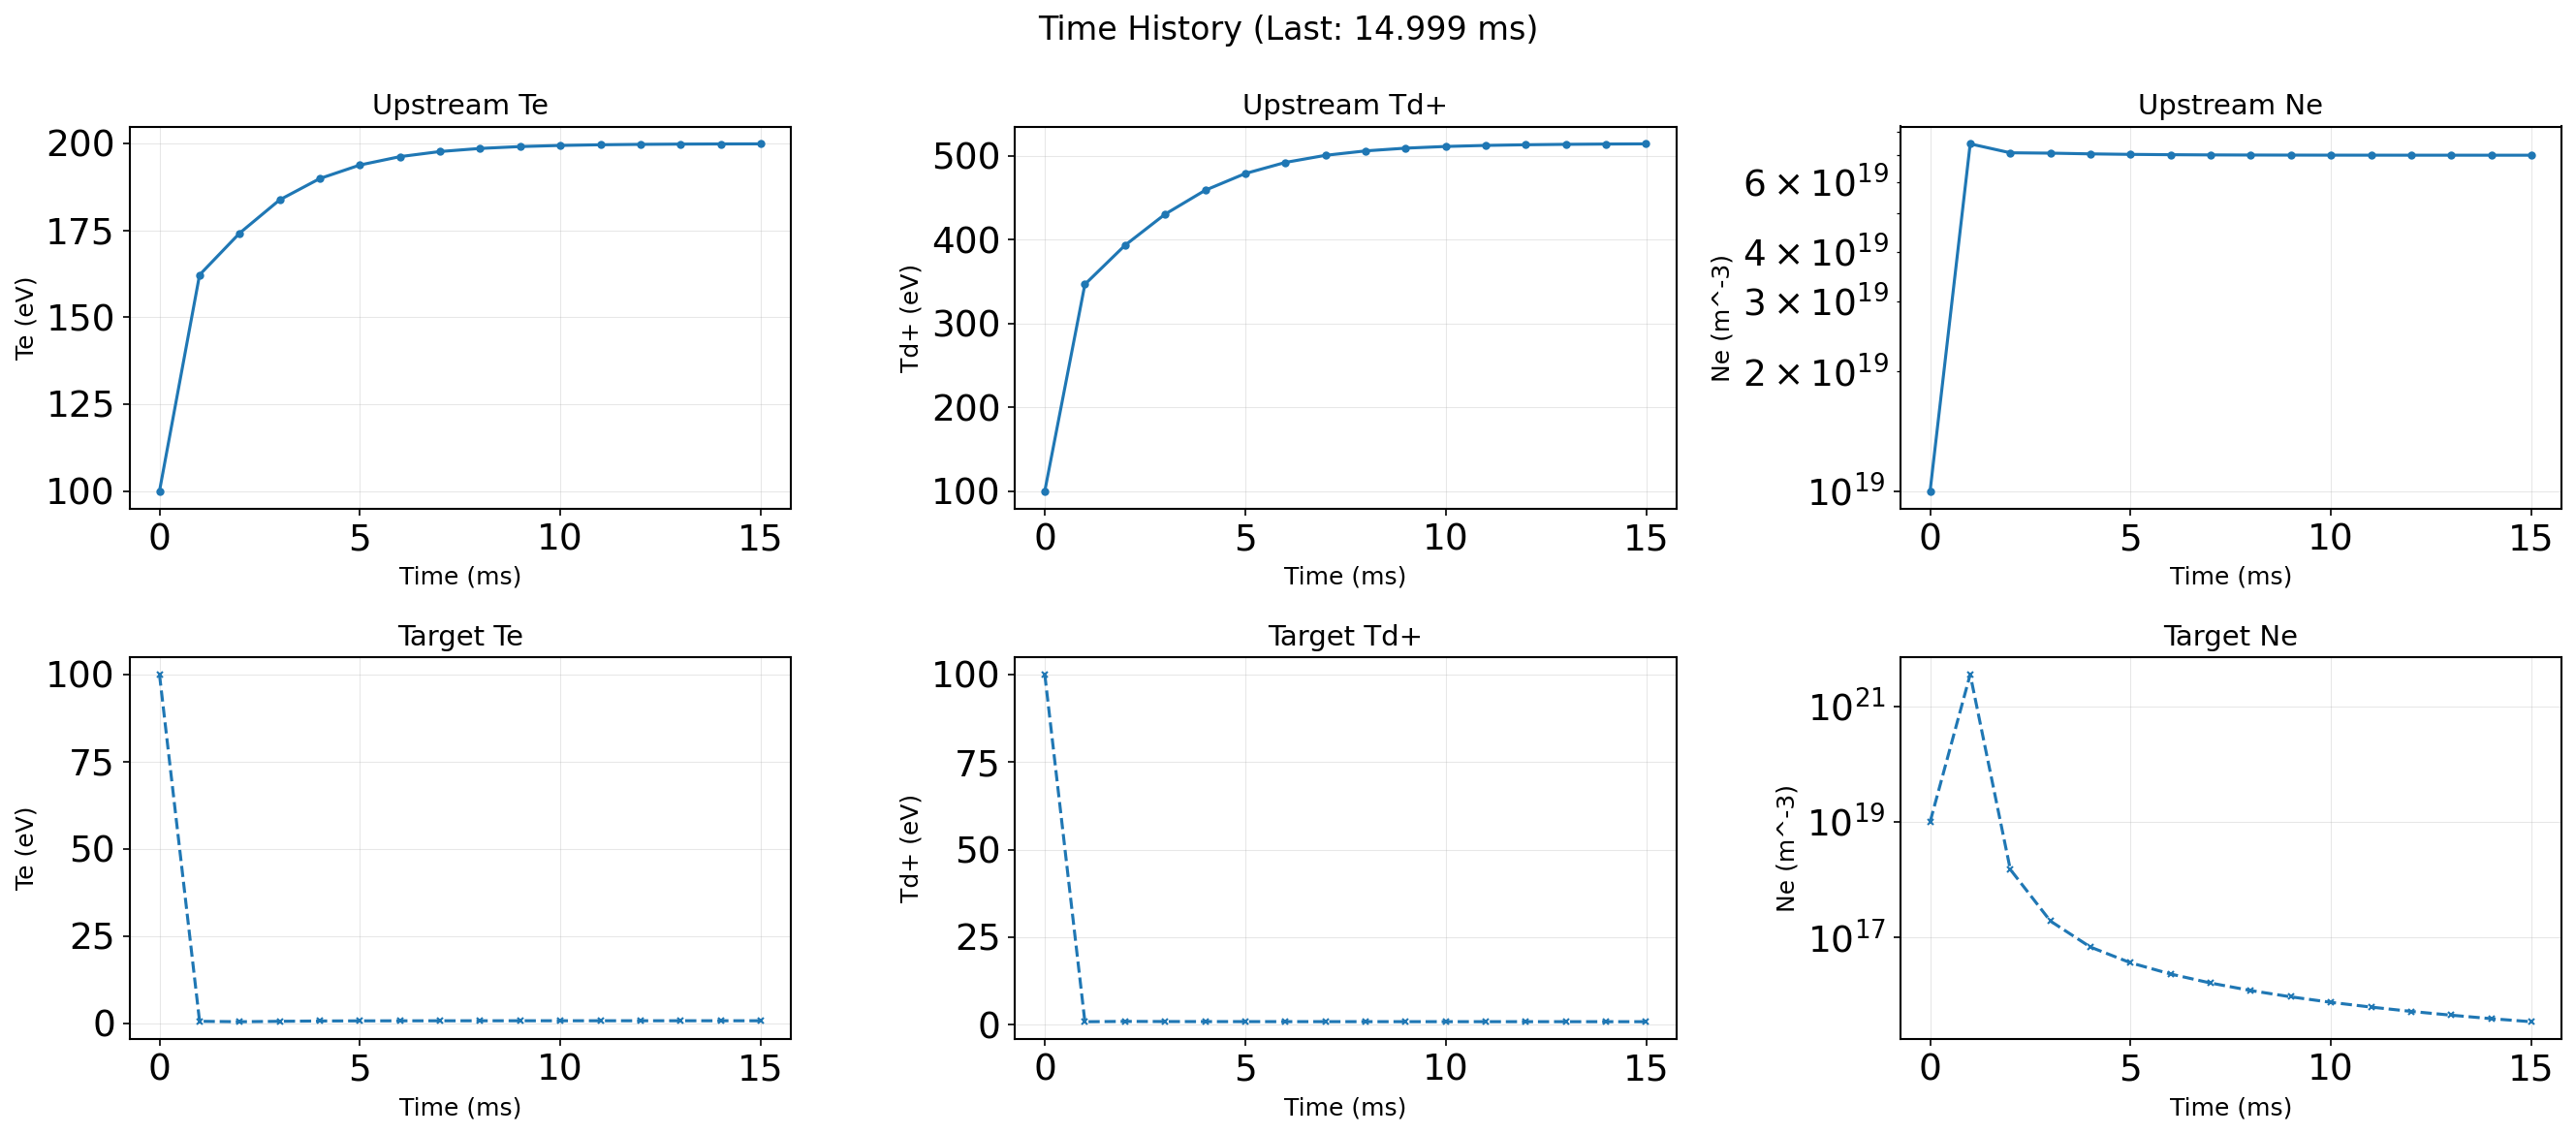

⚡ plot_time_history_optimized completed in 0.773s


In [10]:
plot_time_history(ds, variables=['Te', 'Td+', 'Ne'])

In [ ]:
plot_profiles_animation_optimized

TypeError: plot_profiles_animation_optimized() got an unexpected keyword argument 'time_slices'